In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import LeaveOneGroupOut

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

import xgboost as xgb


In [3]:
training = pd.read_csv(
    "../data/processed/training_dataset_verified_v2.csv"
)

training["Year"] = training["Year"].astype(int)

print("Shape:", training.shape)

print("\nClass distribution:")
print(training["Outbreak_Label"].value_counts())

print("\nDistricts:")
print(training["District"].value_counts())

print("\nYears:")
print(sorted(training["Year"].unique()))

Shape: (46, 30)

Class distribution:
Outbreak_Label
1    23
0    23
Name: count, dtype: int64

Districts:
District
Uttara Kannada    9
Kodagu            9
Shivamogga        4
Chikkamagaluru    4
Wayanad           4
Kannur            4
North Goa         4
South Goa         4
Sindhudurg        4
Name: count, dtype: int64

Years:
[np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [4]:
assert training["Outbreak_Label"].nunique() == 2, \
    "Target must contain both classes."

assert training[
    ["State", "District", "Year"]
].duplicated().sum() == 0, \
    "Duplicate district-year records detected."

print("Dataset integrity checks passed.")

Dataset integrity checks passed.


In [6]:
feature_columns = [

    "Temperature",
    "Rainfall",
    "NDVI",
    "Forest_Loss",
    "Elevation",
    "Temp_Range"

]

X = training[feature_columns].copy()

y = training["Outbreak_Label"].astype(int)

groups = training["District"]

In [7]:
print("Features:")
print(feature_columns)

print("\nMissing values:")
print(X.isnull().sum())

print("\nFeature statistics:")
display(X.describe().T)

Features:
['Temperature', 'Rainfall', 'NDVI', 'Forest_Loss', 'Elevation', 'Temp_Range']

Missing values:
Temperature    0
Rainfall       0
NDVI           0
Forest_Loss    0
Elevation      0
Temp_Range     0
dtype: int64

Feature statistics:


,count,mean,std,min,25%,50%,75%,max
Temperature,46.0,27.244502,2.172342e+00,20.748626,27.472496,28.029030,28.345260,30.150000
Rainfall,46.0,2480.532609,8.332220e+02,4.100000,2088.150000,2440.650000,3001.950000,4865.300000
NDVI,46.0,0.586866,2.080331e-16,0.586866,0.586866,0.586866,0.586866,0.586866
Forest_Loss,46.0,0.012775,6.449596e-03,0.003779,0.007025,0.011180,0.019144,0.021077
Elevation,46.0,455.275656,2.726952e+02,71.222575,161.866722,429.982021,682.786387,890.594716
Temp_Range,46.0,18.847826,3.720677e+00,9.800000,16.525000,19.000000,20.300000,27.100000


In [8]:
models = {

    "Dummy Baseline":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                DummyClassifier(
                    strategy="most_frequent"
                )
            )
        ]),


    "Logistic Regression":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),


    "Decision Tree":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=3,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),


    "Random Forest":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=3,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]),


    "XGBoost":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                xgb.XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",

                    n_estimators=150,
                    learning_rate=0.05,

                    max_depth=2,
                    min_child_weight=2,

                    subsample=0.8,
                    colsample_bytree=0.8,

                    random_state=42,
                    n_jobs=-1
                )
            )
        ])
}

In [9]:
logo = LeaveOneGroupOut()

print(
    "Number of spatial validation folds:",
    logo.get_n_splits(
        X,
        y,
        groups
    )
)

Number of spatial validation folds: 9


In [10]:
def logo_predictions(model_name, pipeline):

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = clone(pipeline)

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:, 1]


        fold_df = training.iloc[
            test_idx
        ][
            [
                "State",
                "District",
                "Year"
            ]
        ].copy()


        fold_df["Actual"] = (
            y_test.values
        )

        fold_df["Predicted"] = (
            predictions
        )

        fold_df["Probability"] = (
            probabilities
        )

        fold_df["Fold"] = fold

        fold_df["Model"] = (
            model_name
        )

        fold_results.append(
            fold_df
        )


    return pd.concat(
        fold_results,
        ignore_index=True
    )

In [11]:
oof_results = []

for model_name, pipeline in models.items():

    print(
        f"Evaluating: {model_name}"
    )

    predictions = logo_predictions(
        model_name,
        pipeline
    )

    oof_results.append(
        predictions
    )


oof_predictions = pd.concat(
    oof_results,
    ignore_index=True
)

print("\nEvaluation complete.")

oof_predictions.head()

Evaluating: Dummy Baseline
Evaluating: Logistic Regression
Evaluating: Decision Tree
Evaluating: Random Forest
Evaluating: XGBoost

Evaluation complete.


,State,District,Year,Actual,Predicted,Probability,Fold,Model
0,Karnataka,Chikkamagaluru,2021,1,0,0.0,1,Dummy Baseline
1,Karnataka,Chikkamagaluru,2022,0,0,0.0,1,Dummy Baseline
2,Karnataka,Chikkamagaluru,2023,1,0,0.0,1,Dummy Baseline
3,Karnataka,Chikkamagaluru,2024,1,0,0.0,1,Dummy Baseline
4,Kerala,Kannur,2015,0,1,1.0,2,Dummy Baseline


In [12]:
metrics = []

for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    y_true = result["Actual"]
    y_pred = result["Predicted"]
    y_prob = result["Probability"]


    metrics.append({

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                y_prob
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                y_prob
            )
    })


model_results = pd.DataFrame(
    metrics
)

In [13]:
model_results = (
    model_results
    .sort_values(
        by=[
            "F1",
            "PR_AUC",
            "Balanced_Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.round(3)
)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree,0.543,0.543,0.531,0.739,0.618,0.354,0.437
1,XGBoost,0.500,0.500,0.500,0.565,0.531,0.471,0.473
2,Random Forest,0.435,0.435,0.448,0.565,0.500,0.319,0.397
3,Logistic Regression,0.478,0.478,0.478,0.478,0.478,0.446,0.446
4,Dummy Baseline,0.174,0.174,0.059,0.043,0.050,0.174,0.481


In [14]:
model_results.to_csv(
    "../paper/tables/"
    "table_model_comparison_logo.csv",
    index=False
)

oof_predictions.to_csv(
    "../data/processed/"
    "model_oof_predictions_logo.csv",
    index=False
)

print(
    "Model comparison and OOF predictions saved."
)

Model comparison and OOF predictions saved.


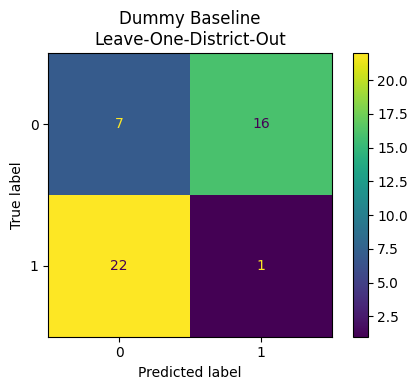

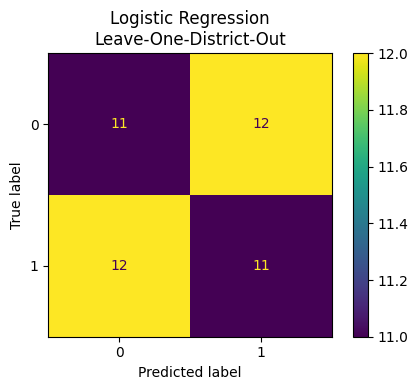

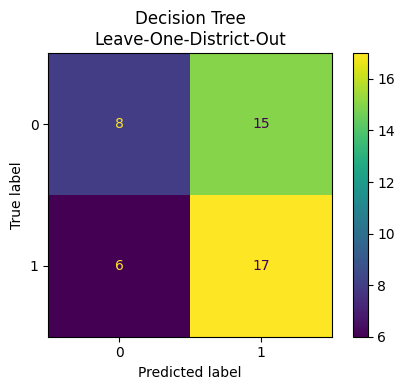

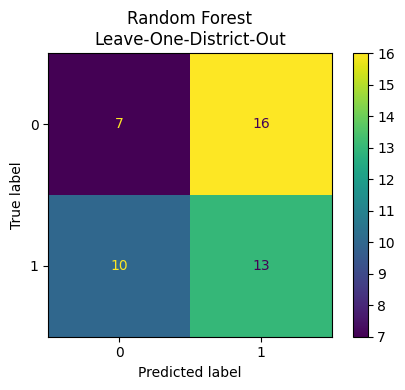

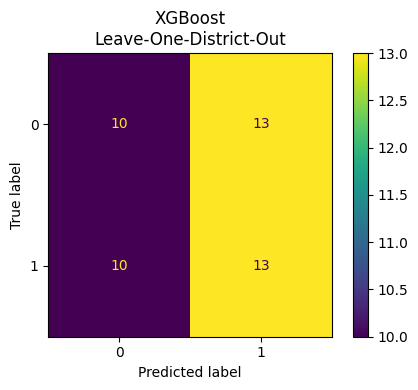

In [15]:
for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    ConfusionMatrixDisplay.from_predictions(
        result["Actual"],
        result["Predicted"],
        ax=ax
    )

    ax.set_title(
        f"{model_name}\nLeave-One-District-Out"
    )

    plt.tight_layout()

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"paper/figures/"
        f"confusion_matrix_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

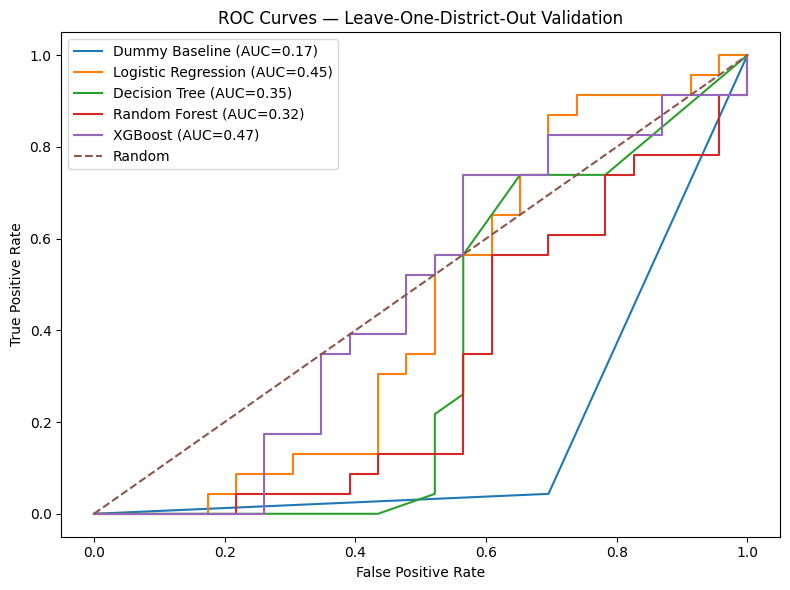

In [16]:
plt.figure(
    figsize=(8, 6)
)

for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    fpr, tpr, _ = roc_curve(
        result["Actual"],
        result["Probability"]
    )

    auc = roc_auc_score(
        result["Actual"],
        result["Probability"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc:.2f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves — Leave-One-District-Out Validation"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../paper/figures/"
    "figure_model_roc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

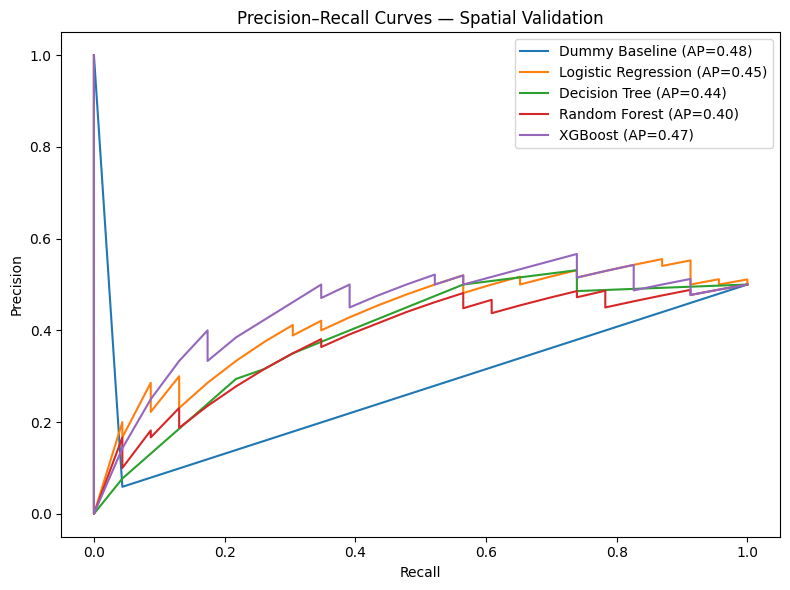

In [17]:
plt.figure(
    figsize=(8, 6)
)

for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    precision, recall, _ = (
        precision_recall_curve(
            result["Actual"],
            result["Probability"]
        )
    )

    score = average_precision_score(
        result["Actual"],
        result["Probability"]
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{model_name} "
            f"(AP={score:.2f})"
        )
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision–Recall Curves — Spatial Validation"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../paper/figures/"
    "figure_precision_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
district_performance = []

for model_name in models.keys():

    subset = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    for district, group in subset.groupby(
        "District"
    ):

        district_performance.append({

            "Model":
                model_name,

            "District":
                district,

            "Observations":
                len(group),

            "Correct":
                (
                    group["Actual"]
                    == group["Predicted"]
                ).sum(),

            "Accuracy":
                (
                    group["Actual"]
                    == group["Predicted"]
                ).mean(),

            "Actual_Outbreaks":
                group["Actual"].sum(),

            "Predicted_Outbreaks":
                group["Predicted"].sum()
        })


district_results = pd.DataFrame(
    district_performance
)

display(
    district_results
)

,Model,District,Observations,Correct,Accuracy,Actual_Outbreaks,Predicted_Outbreaks
0,Dummy Baseline,Chikkamagaluru,4,1,0.250000,3,0
1,Dummy Baseline,Kannur,4,0,0.000000,0,4
2,Dummy Baseline,Kodagu,9,0,0.000000,0,9
3,Dummy Baseline,North Goa,4,0,0.000000,4,0
4,Dummy Baseline,Shivamogga,4,0,0.000000,4,0
5,Dummy Baseline,Sindhudurg,4,0,0.000000,4,0
6,Dummy Baseline,South Goa,4,1,0.250000,1,4
7,Dummy Baseline,Uttara Kannada,9,4,0.444444,5,0
8,Dummy Baseline,Wayanad,4,2,0.500000,2,0
9,Logistic Regression,Chikkamagaluru,4,3,0.750000,3,4


In [19]:
district_results.to_csv(
    "../paper/tables/"
    "table_district_validation_results.csv",
    index=False
)

In [20]:
best_model_name = (
    model_results.iloc[0]["Model"]
)

print(
    "Best model based on "
    "F1 → PR-AUC → Balanced Accuracy:"
)

print(
    best_model_name
)

Best model based on F1 → PR-AUC → Balanced Accuracy:
Decision Tree


In [21]:
train_mask = (
    training["Year"] <= 2022
)

test_mask = (
    training["Year"] >= 2023
)


X_temporal_train = X[
    train_mask
]

y_temporal_train = y[
    train_mask
]

X_temporal_test = X[
    test_mask
]

y_temporal_test = y[
    test_mask
]


print(
    "Temporal training observations:",
    len(X_temporal_train)
)

print(
    "Temporal test observations:",
    len(X_temporal_test)
)

print("\nTest class distribution:")

print(
    y_temporal_test.value_counts()
)

Temporal training observations: 38
Temporal test observations: 8

Test class distribution:
Outbreak_Label
1    5
0    3
Name: count, dtype: int64


In [22]:
temporal_metrics = []

for model_name, pipeline in models.items():

    model = clone(
        pipeline
    )

    model.fit(
        X_temporal_train,
        y_temporal_train
    )

    pred = model.predict(
        X_temporal_test
    )

    prob = model.predict_proba(
        X_temporal_test
    )[:, 1]


    row = {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_temporal_test,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_temporal_test,
                pred
            ),

        "Precision":
            precision_score(
                y_temporal_test,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_temporal_test,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_temporal_test,
                pred,
                zero_division=0
            )
    }


    if (
        y_temporal_test.nunique()
        == 2
    ):

        row["ROC_AUC"] = (
            roc_auc_score(
                y_temporal_test,
                prob
            )
        )

        row["PR_AUC"] = (
            average_precision_score(
                y_temporal_test,
                prob
            )
        )

    temporal_metrics.append(
        row
    )


temporal_results = pd.DataFrame(
    temporal_metrics
)

display(
    temporal_results.round(3)
)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Baseline,0.375,0.500,0.000,0.0,0.000,0.500,0.625
1,Logistic Regression,0.750,0.667,0.714,1.0,0.833,0.667,0.710
2,Decision Tree,0.875,0.833,0.833,1.0,0.909,0.800,0.807
3,Random Forest,0.625,0.633,0.750,0.6,0.667,0.667,0.743
4,XGBoost,0.500,0.400,0.571,0.8,0.667,0.333,0.626


In [23]:
temporal_results.to_csv(
    "../paper/tables/"
    "table_temporal_validation.csv",
    index=False
)

In [24]:
best_pipeline = clone(
    models[best_model_name]
)

best_pipeline.fit(
    X,
    y
)

print(
    f"{best_model_name} fitted "
    "on the complete verified dataset."
)

Decision Tree fitted on the complete verified dataset.


In [26]:
model_path = (
    "../outputs/models/"
    "kfd_outbreak_model_v1.pkl"
)

joblib.dump(
    best_pipeline,
    model_path
)

print(
    "Saved:",
    model_path
)

Saved: C:/Users/chowd/Zoonotic-Spillover-Predictor/outputs/models/kfd_outbreak_model_v1.pkl


In [27]:
metadata = {

    "model_name":
        best_model_name,

    "target":
        "Outbreak_Label",

    "target_definition":
        "KFD outbreak occurrence",

    "features":
        feature_columns,

    "validation":
        "Leave-One-District-Out",

    "training_observations":
        int(len(training)),

    "districts":
        sorted(
            training["District"]
            .unique()
            .tolist()
        ),

    "year_min":
        int(training["Year"].min()),

    "year_max":
        int(training["Year"].max())
}


with open(
    "../outputs/models/kfd_outbreak_model_v1_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


print(
    "Model metadata saved."
)

Model metadata saved.


In [28]:
final_estimator = (
    best_pipeline
    .named_steps["model"]
)


if hasattr(
    final_estimator,
    "feature_importances_"
):

    importance_values = (
        final_estimator
        .feature_importances_
    )


elif hasattr(
    final_estimator,
    "coef_"
):

    importance_values = (
        np.abs(
            final_estimator
            .coef_[0]
        )
    )


else:

    importance_values = None

In [29]:
if importance_values is not None:

    feature_importance = pd.DataFrame({

        "Feature":
            feature_columns,

        "Importance":
            importance_values

    }).sort_values(
        "Importance",
        ascending=False
    )


    display(
        feature_importance
    )


    feature_importance.to_csv(
        "../paper/tables/"
        "table_feature_importance.csv",
        index=False
    )

,Feature,Importance
3,Forest_Loss,0.483483
0,Temperature,0.435708
1,Rainfall,0.080808
2,NDVI,0.000000
4,Elevation,0.000000
5,Temp_Range,0.000000


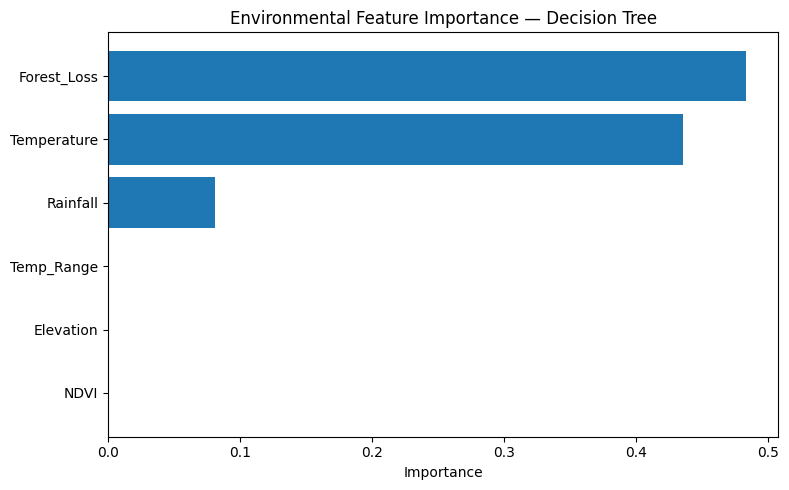

In [30]:
if importance_values is not None:

    plot_data = (
        feature_importance
        .sort_values(
            "Importance"
        )
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.barh(
        plot_data["Feature"],
        plot_data["Importance"]
    )

    plt.xlabel(
        "Importance"
    )

    plt.title(
        f"Environmental Feature Importance — {best_model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        "../paper/figures/"
        "figure_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [31]:
print("=" * 70)
print("REAL KFD MACHINE LEARNING PIPELINE COMPLETE")
print("=" * 70)

print(
    "\nTraining observations:",
    len(training)
)

print(
    "Districts:",
    training["District"].nunique()
)

print("\nClass balance:")
print(
    y.value_counts()
)

print(
    "\nBest model:",
    best_model_name
)

print(
    "\nSaved model:",
    model_path
)

print(
    "\nPrimary validation:",
    "Leave-One-District-Out"
)

print("\nModel comparison:")

display(
    model_results.round(3)
)

print("\nTemporal validation:")

display(
    temporal_results.round(3)
)

REAL KFD MACHINE LEARNING PIPELINE COMPLETE

Training observations: 46
Districts: 9

Class balance:
Outbreak_Label
1    23
0    23
Name: count, dtype: int64

Best model: Decision Tree

Saved model: C:/Users/chowd/Zoonotic-Spillover-Predictor/outputs/models/kfd_outbreak_model_v1.pkl

Primary validation: Leave-One-District-Out

Model comparison:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree,0.543,0.543,0.531,0.739,0.618,0.354,0.437
1,XGBoost,0.500,0.500,0.500,0.565,0.531,0.471,0.473
2,Random Forest,0.435,0.435,0.448,0.565,0.500,0.319,0.397
3,Logistic Regression,0.478,0.478,0.478,0.478,0.478,0.446,0.446
4,Dummy Baseline,0.174,0.174,0.059,0.043,0.050,0.174,0.481



Temporal validation:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Baseline,0.375,0.500,0.000,0.0,0.000,0.500,0.625
1,Logistic Regression,0.750,0.667,0.714,1.0,0.833,0.667,0.710
2,Decision Tree,0.875,0.833,0.833,1.0,0.909,0.800,0.807
3,Random Forest,0.625,0.633,0.750,0.6,0.667,0.667,0.743
4,XGBoost,0.500,0.400,0.571,0.8,0.667,0.333,0.626


In [32]:
feature_sets = {

    "Dynamic Only": [
        "Temperature",
        "Rainfall",
        "NDVI",
        "Temp_Range"
    ],

    "Static Only": [
        "Forest_Loss",
        "Elevation"
    ],

    "Combined": [
        "Temperature",
        "Rainfall",
        "NDVI",
        "Forest_Loss",
        "Elevation",
        "Temp_Range"
    ]
}

In [33]:
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_feature_set(
    feature_set_name,
    features,
    model_name,
    pipeline
):

    X_temp = training[features].copy()

    all_true = []
    all_pred = []
    all_prob = []

    for train_idx, test_idx in logo.split(
        X_temp,
        y,
        groups
    ):

        X_train = X_temp.iloc[train_idx]
        X_test = X_temp.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = clone(pipeline)

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        prob = model.predict_proba(
            X_test
        )[:, 1]

        all_true.extend(
            y_test.tolist()
        )

        all_pred.extend(
            pred.tolist()
        )

        all_prob.extend(
            prob.tolist()
        )

    return {

        "Feature_Set":
            feature_set_name,

        "Model":
            model_name,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                all_true,
                all_pred
            ),

        "Precision":
            precision_score(
                all_true,
                all_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                all_true,
                all_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                all_true,
                all_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                all_true,
                all_prob
            ),

        "PR_AUC":
            average_precision_score(
                all_true,
                all_prob
            )
    }

In [34]:
ablation_results = []

for feature_set_name, features in feature_sets.items():

    for model_name in [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ]:

        result = evaluate_feature_set(

            feature_set_name,
            features,

            model_name,
            models[model_name]
        )

        ablation_results.append(
            result
        )


ablation_df = pd.DataFrame(
    ablation_results
)

ablation_df = ablation_df.sort_values(
    [
        "Balanced_Accuracy",
        "F1"
    ],
    ascending=False
)

display(
    ablation_df.round(3)
)

,Feature_Set,Model,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Dynamic Only,Random Forest,0.565,0.571,0.522,0.545,0.544,0.501
9,Combined,Decision Tree,0.543,0.531,0.739,0.618,0.354,0.437
0,Dynamic Only,Logistic Regression,0.543,0.542,0.565,0.553,0.491,0.471
1,Dynamic Only,Decision Tree,0.500,0.500,0.652,0.566,0.477,0.483
11,Combined,XGBoost,0.500,0.500,0.565,0.531,0.471,0.473
8,Combined,Logistic Regression,0.478,0.478,0.478,0.478,0.446,0.446
3,Dynamic Only,XGBoost,0.435,0.429,0.391,0.409,0.476,0.480
10,Combined,Random Forest,0.435,0.448,0.565,0.500,0.319,0.397
5,Static Only,Decision Tree,0.304,0.345,0.435,0.385,0.208,0.373
4,Static Only,Logistic Regression,0.283,0.333,0.435,0.377,0.342,0.461


In [35]:
ablation_df.to_csv(

    "../paper/tables/"
    "table_feature_set_ablation.csv",

    index=False
)

print(
    "Feature-set ablation results saved."
)

Feature-set ablation results saved.


In [36]:
dt_results = oof_predictions[
    oof_predictions["Model"]
    == "Decision Tree"
]

tn, fp, fn, tp = confusion_matrix(
    dt_results["Actual"],
    dt_results["Predicted"]
).ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

print("Decision Tree spatial validation")
print("--------------------------------")
print("True Positives :", tp)
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)

print(
    "\nSensitivity:",
    round(sensitivity, 3)
)

print(
    "Specificity:",
    round(specificity, 3)
)

Decision Tree spatial validation
--------------------------------
True Positives : 17
True Negatives : 8
False Positives: 15
False Negatives: 6

Sensitivity: 0.739
Specificity: 0.348


In [37]:
final_feature_columns = [
    "Temperature",
    "Rainfall",
    "NDVI",
    "Temp_Range"
]

X_final = training[
    final_feature_columns
].copy()

y_final = training[
    "Outbreak_Label"
].astype(int)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

final_model = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "model",
        RandomForestClassifier(

            n_estimators=500,

            max_depth=3,

            min_samples_leaf=2,

            class_weight="balanced",

            random_state=42,

            n_jobs=-1
        )
    )
])

In [39]:
final_model.fit(
    X_final,
    y_final
)

print(
    "Final Dynamic Random Forest trained."
)

Final Dynamic Random Forest trained.


In [40]:
import joblib
import os

final_model_path = (
    "../outputs/models/"
    "kfd_outbreak_model_v2.pkl"
)

joblib.dump(
    final_model,
    final_model_path
)

print(
    "Saved:",
    final_model_path
)

Saved: C:/Users/chowd/Zoonotic-Spillover-Predictor/outputs/models/kfd_outbreak_model_v2.pkl


In [41]:
import json

final_metadata = {

    "model_version":
        "v2",

    "model_name":
        "Random Forest",

    "feature_set":
        "Dynamic environmental features",

    "features":
        final_feature_columns,

    "target":
        "Outbreak_Label",

    "target_definition":
        "Reported KFD outbreak occurrence",

    "training_observations":
        int(len(training)),

    "districts":
        int(
            training[
                "District"
            ].nunique()
        ),

    "primary_validation":
        "Leave-One-District-Out",

    "spatial_balanced_accuracy":
        0.565,

    "spatial_precision":
        0.571,

    "spatial_recall":
        0.522,

    "spatial_f1":
        0.545,

    "spatial_roc_auc":
        0.544,

    "spatial_pr_auc":
        0.501,

    "intended_use":
        (
            "Experimental environmental "
            "KFD outbreak-risk classification"
        ),

    "limitations":
        (
            "Small observational dataset; "
            "limited cross-district predictive "
            "performance; model score is not "
            "a calibrated epidemiological probability."
        )
}


with open(
    "../outputs/models/"
    "kfd_outbreak_model_v2_metadata.json",
    "w"
) as file:

    json.dump(
        final_metadata,
        file,
        indent=4
    )

print(
    "V2 model metadata saved."
)

V2 model metadata saved.


In [42]:
rf = final_model.named_steps[
    "model"
]

final_importance = pd.DataFrame({

    "Feature":
        final_feature_columns,

    "Importance":
        rf.feature_importances_

}).sort_values(
    "Importance",
    ascending=False
)

display(
    final_importance
)

,Feature,Importance
0,Temperature,0.475723
3,Temp_Range,0.268019
1,Rainfall,0.256258
2,NDVI,0.000000


In [43]:
final_importance.to_csv(

    "../paper/tables/"
    "table_final_model_feature_importance.csv",

    index=False
)

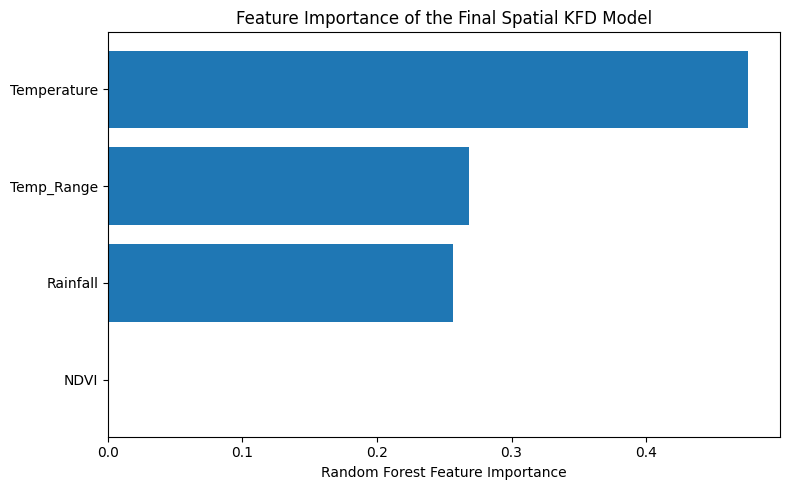

In [44]:
plot_data = (
    final_importance
    .sort_values("Importance")
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel(
    "Random Forest Feature Importance"
)

plt.title(
    "Feature Importance of the Final Spatial KFD Model"
)

plt.tight_layout()

plt.savefig(
    "../paper/figures/"
    "figure_final_model_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()